## Taller computacional
Se tiene el siguente modelo ODE que representa la operación de un bioreactor en modo fed-batch.

In [199]:
# Import required libraries
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [200]:
# Define the fed-batch ODE system
def fed_batch(t, x, u, Csf):
    """
    Function to calculate the ODEs for the fed-batch model.
    """
    # Unpack state variables
    X, S, P, V = x  # Biomass (g), Substrate (g), Product (g), Volume (L)
    
    # Constitutive equations
    cs = S / V                       # Substrate concentration in reactor (g/L)
    mu = 0.125 * cs                  # Growth rate (1/h)
    sigma = mu / 0.135               # Substrate consumption rate (g S / g X / h)
    pi = -384 * mu**2 + 134 * mu     # Product formation rate (g P / g X / h)
    
    # Differential equations
    dXdt = mu * X                    # Biomass growth
    dSdt = -sigma * X + u * Csf      # Substrate consumption
    dPdt = pi * X                    # Product formation
    dVdt = u                         # Volume change

    # return [dXdt, dSdt, dPdt, dVdt]
    return np.array([dXdt, dSdt, dPdt, dVdt])  # Return as a NumPy array

In [201]:
# Define Euler's Method
def Euler_method(f, t0, tf, x0, n, u, p):
    """
    Explicit Euler method for integrating ODEs.
    """
    h = tf / n  # Step size
    t = np.zeros(n+1)
    # x = np.array((n+1)*[x0])
    x = np.zeros((n+1, len(x0)))  # State variable array (n+1 x len(x0))
    t[0] = t0
    x[0] = x0
    
    for k in range(n):
        x[k+1] = x[k] + h * f(t[k], x[k], u[k], p)
        t[k+1] = t[k] + h
        
    return t, x

In [202]:
# Define RK4 Method
def RK4_method(f, t0, tf, x0, n, u, p):
    """
    Runge-Kutta 4th order method for integrating ODEs.
    """
    h = tf / n
    t = np.zeros(n+1)
    x = np.array((n+1)*[x0])
    t[0] = t0
    x[0] = x0
    
    for k in range(n):
        k1 = f(t[k], x[k], u[k], p)
        k2 = f(t[k]+h/2, x[k]+(h/2)*k1, u[k], p)
        k3 = f(t[k]+h/2, x[k]+(h/2)*k2, u[k], p)
        k4 = f(t[k]+h, x[k]+h*k3, u[k], p)
        x[k+1] = x[k] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        t[k+1] = t[k] + h
                
    return t, x

In [203]:
# Define parameters for integration
tf = 40  # Final time for simulation (hours)
x0 = [0.1, 14, 0, 5]  # Initial state [X, S, P, V]
n = 1000  # Number of steps
u = np.full(n+1, 0.5)  # Constant feed rate (L/h)
Csf = 2.8  # Substrate concentration in feed (g/L)

In [204]:
# Integration using Euler and RK4 methods
t1, x1 = Euler_method(fed_batch, 0, tf, x0, n, u, Csf)
t2, x2 = RK4_method(fed_batch, 0, tf, x0, n, u, Csf)

In [205]:
# Integration using solve_ivp
tspan = (0, tf)
sol = solve_ivp(fed_batch, tspan, x0, method='BDF', args=(0.5, Csf))
t3 = sol.t
x3 = sol.y.T

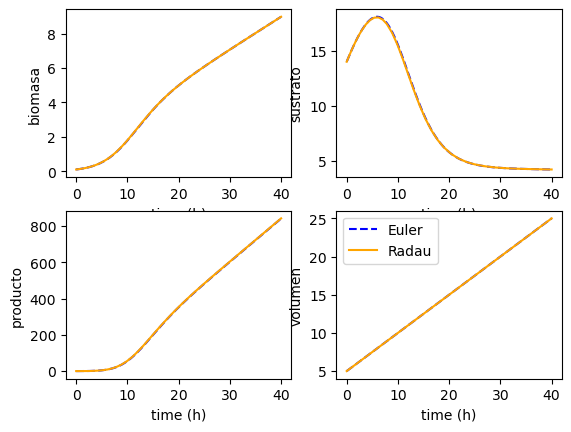

In [206]:
# Visualization (Euler vs Radau)
names = ['biomasa', 'sustrato', 'producto', 'volumen']
plt.figure()
for i in range(len(x0)):
    # plt.grid(True)
    plt.subplot(2, 2, i+1)
    # plt.plot(t1, np.array(x1)[:, i], ':')
    # plt.plot(t3, x3[:, i])
    plt.plot(t1, np.array(x1)[:, i], linestyle='--', color='blue', label='Euler')
    plt.plot(t3, x3[:, i], linestyle='-', color='orange', label='Radau')
    plt.xlabel('time (h)')
    plt.ylabel(names[i])
plt.legend(['Euler', 'Radau'])

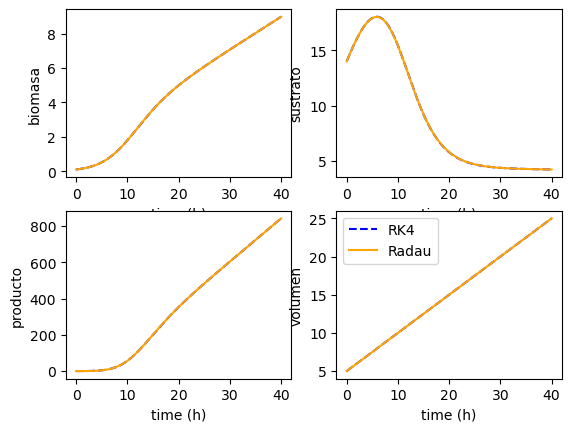

In [207]:
# Visualization (RK4 vs Radau)
plt.figure()
for i in range(len(x0)):
    # plt.grid(True)
    plt.subplot(2, 2, i+1)
    # plt.plot(t2, np.array(x2)[:, i], ':')
    # plt.plot(t3, x3[:, i])
    plt.plot(t2, np.array(x2)[:, i], linestyle='--', color='blue', label='RK4')
    plt.plot(t3, x3[:, i], linestyle='-', color='orange', label='Radau')
    plt.xlabel('time (h)')
    plt.ylabel(names[i])
plt.legend(['RK4', 'Radau'])
plt.show()

## 3 - Optimización

In [208]:
# Objective function (multi-objective)
def cost_function(dv, n, x0, Csf, w):
    """
    Calculates the objective function J(u, tf).
    
    Parameters:
    dv (array): Decision variable vector (control inputs).
    n (int): Number of time steps.
    x0 (array): Initial conditions [X, S, P, V].
    Csf (float): Feed substrate concentration.
    w (float): Weight for the objective function.
    
    Returns:
    J (float): Objective function value.
    """
    # Integrate the system using RK4 with the control inputs
    t, x = RK4_method(fed_batch, 0, tf, x0, n, dv, Csf)
    
    # Objective terms
    j1 = -x[-1, 2]  # Maximize final product (negative for minimization)
    j2 = np.sum(dv)  # Minimize total feed rate
    
    # Combine objectives
    J = w * j1 + (1 - w) * j2
    
    return J

In [209]:
def restriccion_volumen(dv, n, x0, Csf):
    """
    Calculates the volume constraint for the reactor.
    
    Parameters:
    dv (array): Decision variable vector (control inputs).
    n (int): Number of time steps.
    x0 (array): Initial conditions [X, S, P, V].
    Csf (float): Feed substrate concentration.
    
    Returns:
    g (array): Volume constraint violations at each time step.
    """
    # Integrate the system using RK4 with the control inputs
    t, x = RK4_method(fed_batch, 0, tf, x0, n, dv, Csf)
    
    # Extract reactor volume at each time step
    V = x[:, 3]  # Volume is the 4th state variable (index 3)
    
    # Define maximum volume
    V_max = 25  # Example maximum allowable volume (L)
    
    # Calculate volume constraints
    g = V - V_max  # Constraint violations (should be <= 0)
    
    return g


In [210]:
def restriccion_sustrato(dv, n, x0, Csf):
    """
    Calculates the minimum substrate constraint.
    
    Parameters:
    dv (array): Decision variable vector (control inputs).
    n (int): Number of time steps.
    x0 (array): Initial conditions [X, S, P, V].
    Csf (float): Feed substrate concentration.
    
    Returns:
    g (float): Substrate constraint violation (should be <= 0).
    """
    # Integrate the system using RK4 with the control inputs
    t, x = RK4_method(fed_batch, 0, tf, x0, n, dv, Csf)
    
    # Extract substrate at each time step
    S = x[:, 1]  # Substrate is the 2nd state variable (index 1)
    
    # Define minimum substrate level
    S_min = 2  # Example minimum substrate level (g)
    
    # Calculate substrate constraint
    g = S_min - np.min(S)  # Constraint violation (should be <= 0)
    
    return g


In [211]:
# %% definición de inputs para función optimize
from scipy.optimize import Bounds # had to add this line of code to clear Bounds error

xL = [0.0]*(n+1) # limite inferior de u
tf_L = 20.0 # limite inferior de tf
xL = np.append(xL,20.0) # limite inferior de todas las variables de decision
xU = [2.0]*(n+1) # limite superior de u
tf_U = 40.0 # limite superior de tf
xU = np.append(xU,40.0) # limite superior de todas las variables de decision
bounds = Bounds(xL, xU) # se juntan los limites xL y xU en una sola variable
# configuración de las restriciones de desiguladad
con1 = {'type': 'ineq', 'fun': restriccion_volumen, 'args': (n, x0, Csf)}
con2 = {'type': 'ineq', 'fun': restriccion_sustrato, 'args': (n, x0, Csf)}
cons = ([con1,con2])
# valor inicial de iteración del algoritmo (initial guess)
u = np.random.uniform(low=0, high = 2, size=(n+1)) # valor aleatorio entre 0 y 2 para u
initial_guess = np.append(u,20.0) # se concatena valor inicial de iteraicón de tf
options = {'disp': True}
algorithm = 'SLSQP'

In [212]:
from scipy.optimize import minimize # had to add to clear minimize error
w = 0.0

solution = minimize(cost_function,initial_guess, method='SLSQP',\
                    bounds=bounds, args = (n, x0, Csf, w),constraints=cons,
                    options=options)

u_opt = solution.x[:-1]   
tf_opt = solution.x[-1] 

t_opt, x_opt = RK4_method(fed_batch, 0, tf_opt, x0, n, u_opt, Csf)

j1 = -x_opt[-1,2]/tf_opt
j2 = -x_opt[-1,2]/((x_opt[-1,3]-x_opt[0,3])*Csf)
print(f' J1 = {j1} | J2 = {j2}')

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 519.9999999937606
            Iterations: 9
            Function evaluations: 5015
            Gradient evaluations: 5
 J1 = -17.445937269318343 | J2 = -12.461383763954323


Text(0.5, 0, '$t(h)$')

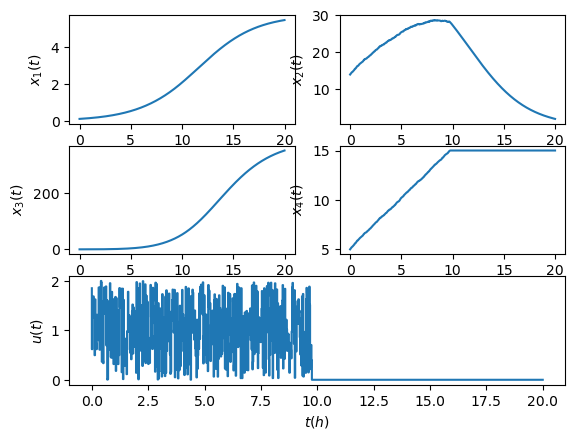

In [213]:
# %% grafico resultados optimización
plt.figure()
plt.subplot(3,2,1)
plt.plot(t_opt,x_opt[:,0])
plt.ylabel(r'$x_{1}(t)$')
plt.subplot(3,2,2)
plt.plot(t_opt,x_opt[:,1])
plt.ylabel(r'$x_{2}(t)$')
plt.subplot(3,2,3)
plt.plot(t_opt,x_opt[:,2])
plt.ylabel(r'$x_{3}(t)$')
plt.subplot(3,2,4)
plt.plot(t_opt,x_opt[:,3])
plt.ylabel(r'$x_{4}(t)$')
plt.subplot(3,2,(5,6))
plt.step(t_opt,u_opt)
plt.ylabel(r'$u(t)$')
plt.xlabel('$t(h)$')

## 4 - Optimización multi-objetivo usando NSGA-II

In [214]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

In [215]:
class batch_moo_problem(ElementwiseProblem):    

    def __init__(self):   
        
        n = 30 # número de elementos finitos
        xL = [0.0]*(n+1) # limite inferior de u
        tf_L = 20.0 # limite inferior de tf        
        xL = np.append(xL,tf_L) # limite inferior de todas las variables de decision        
         
        xU = [2.0]*(n+1) # limite superior de u
        tf_U = 40.0 # limite superior de tf
        xU = np.append(xU,tf_U) # limite superior de todas las variables de decision
        
        # se define las dimensiones del problema
        # debe completar
        # n_var: número de variables de decisión
        # n_obj: número de objetivos
        # n_constr: número de restricciones (volumen + sustrato)
        super().__init__(n_var =n+2 , n_obj =2 , n_constr=2, xl = xL, xu = xU)
        
    def _evaluate(self, dv, out, *args, **kwargs):       
        
        # debe hacer acá el mismo código de la cost_function
        # debe también calcular acá las restriccion del sustrato y restriccion de volumen
        # 
        n = len(dv) - 1  # Number of control variables
        u = dv[:-1]  # Extract control inputs
        tf = dv[-1]  # Extract final time

        # Integrate the system
        t, x = RK4_method(fed_batch, 0, tf, x0, n, u, Csf)

        # Objectives
        j1 = -x[-1, 2] / tf  # Normalize product rate
        j2 = -x[-1, 2] / ((x[-1, 3] - x[0, 3]) * Csf)  # Product rate per substrate

        # Constraints
        g1 = np.max(x[:, 3]) - 25  # Volume constraint (V_max = 25)
        g2 = 2 - np.min(x[:, 1])  # Substrate constraint (S_min = 2) 
            
        out["F"] = [j1, j2]
        # out["G"] = [g]
        out["G"] = [g1, g2]

In [216]:
# %% inicializar el algoritmo
# added the following couple of lines to suppress warning
from pymoo.config import Config
Config.warnings['not_compiled'] = False

problem = batch_moo_problem()
algorithm = NSGA2(pop_size=100, n_offsprings=20, eliminate_duplicates=True)
# ejecutar problema de optimización
res = minimize(problem, algorithm, ("n_gen", 200), verbose=True, seed = 42)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      2 |  0.000000E+00 |  1.042066E+01 |             - |             -
     2 |      120 |      2 |  0.000000E+00 |  8.0146779433 |  0.9595089575 |         ideal
     3 |      140 |      3 |  0.000000E+00 |  6.3979059522 |  0.1037118287 |             f
     4 |      160 |      5 |  0.000000E+00 |  4.9868261451 |  0.4982451624 |         ideal
     5 |      180 |      5 |  0.000000E+00 |  3.5813789925 |  0.1048165301 |         ideal
     6 |      200 |      4 |  0.000000E+00 |  2.4726591389 |  0.1120727873 |             f
     7 |      220 |      4 |  0.000000E+00 |  1.5153267615 |  0.000000E+00 |             f
     8 |      240 |      5 |  0.000000E+00 |  0.8257281878 |  0.0524875515 |             f
     9 |      260 |      5 |  0.000000E+00 |  0.3455828095 |  0.000000E+00 |             f
    10 |      280 |      6 |  0.000000E+00 |  0.0984583263 |  0.5016443898 |         ideal

Text(0, 0.5, '$J_{2}(x)$')

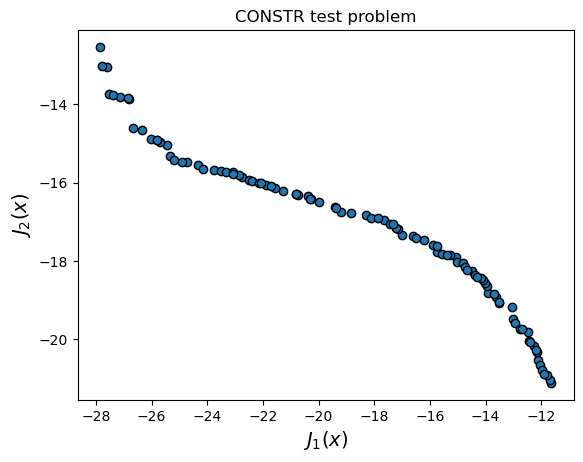

In [217]:
plt.figure()
plt.plot(res.F[:,0], res.F[:,1], 'o', markeredgecolor = 'black')
plt.title('CONSTR test problem')
plt.xlabel(r'$J_{1}(x)$', fontsize = 14)
plt.ylabel(r'$J_{2}(x)$', fontsize = 14)

## Grafica pareto set (variables de desición)¶

In [218]:
ID = 70 # elegir un número de la solución
tf = res.X[ID,-1]
tf

27.224115409617934

In [219]:
n = len(res.X[ID, :-1]) - 1  # This line was added to correct n based on the control inputs cause without this it would thow an mismatch error
t = np.linspace(0,tf,n+1)
t

array([ 0.        ,  0.90747051,  1.81494103,  2.72241154,  3.62988205,
        4.53735257,  5.44482308,  6.3522936 ,  7.25976411,  8.16723462,
        9.07470514,  9.98217565, 10.88964616, 11.79711668, 12.70458719,
       13.6120577 , 14.51952822, 15.42699873, 16.33446925, 17.24193976,
       18.14941027, 19.05688079, 19.9643513 , 20.87182181, 21.77929233,
       22.68676284, 23.59423336, 24.50170387, 25.40917438, 26.3166449 ,
       27.22411541])

Text(0.5, 0, '$t(h)$')

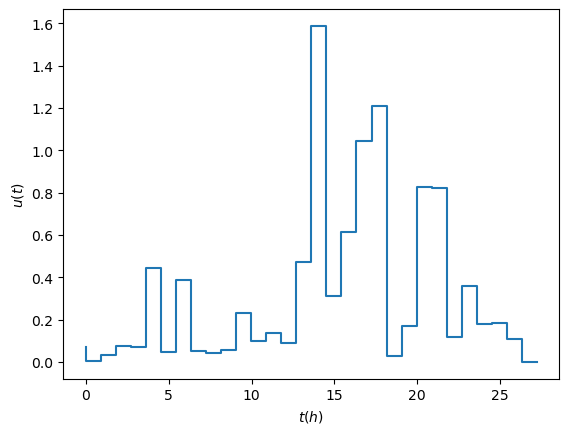

In [220]:
plt.step(t, res.X[ID,:-1])
plt.ylabel(r'$u(t)$')
plt.xlabel('$t(h)$')

In [221]:
print(len(res.X[ID, :-1]))

31
